In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

In [47]:
df = pd.read_csv('./data/dompet_final_cleaned_v2.csv')

In [48]:
df.columns.tolist()

['id',
 'title',
 'rating',
 'reviews',
 'initial_price',
 'final_price',
 'stock',
 'favorite',
 'seller_name',
 'breadcrumb',
 'seller_rating',
 'seller_products',
 'seller_chats_responded_percentage',
 'seller_chat_time_reply',
 'seller_joined_date',
 'seller_followers',
 'sold',
 'brand',
 'gmv_cal',
 'motif',
 'warranty_type',
 'material',
 'warranty_duration',
 'country_of_origin',
 'closure_type',
 'card_slots',
 'coin_slot',
 'leather_texture',
 'leather_finish',
 'leather_type',
 'shipped_from_region',
 'variations_count',
 'voucher_status',
 'image_count',
 'video_count',
 'discount',
 'wallet_type',
 'log_reviews',
 'log_gmv',
 'log_favorite',
 'log_rating',
 'log_sold',
 'rating_credibility']

In [49]:
def zscore_series(s):
    s = pd.to_numeric(s, errors='coerce')
    std = s.std()
    if std == 0 or pd.isna(std):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

In [50]:
# --- Data cleaning & preprocessing ---

# Drop inactive listings
df = df[df['rating'] > 0].copy()

# Winsorize extreme outliers (99th percentile)
for col in ['reviews', 'sold', 'gmv_cal', 'stock']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

# Convert to numeric (safe)
numeric_cols = ['sold', 'reviews', 'final_price', 'stock', 'favorite', 
                'gmv_cal', 'seller_followers', 'seller_products', 'discount']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing critical values
df = df.dropna(subset=['sold', 'rating', 'reviews'])

if 'log_rating' in df.columns:
    df = df.drop(columns=['log_rating'])

print(f"After cleaning: {df.shape[0]:,} rows × {df.shape[1]} cols")

# =========================================================
# STEP 2: CREATE LOG-TRANSFORMED FEATURES
# =========================================================

df['log_reviews'] = np.log1p(df['reviews'])
df['log_final_price'] = np.log1p(pd.to_numeric(df['final_price'], errors='coerce'))
df['log_initial_price'] = np.log1p(pd.to_numeric(df['initial_price'], errors='coerce'))
df['log_stock'] = np.log1p(pd.to_numeric(df['stock'], errors='coerce'))
df['log_favorite'] = np.log1p(pd.to_numeric(df['favorite'], errors='coerce'))
df['log_sold'] = np.log1p(df['sold'])
df['log_gmv_cal'] = np.log1p(pd.to_numeric(df['gmv_cal'], errors='coerce'))
df['log_seller_followers'] = np.log1p(pd.to_numeric(df['seller_followers'], errors='coerce'))
df['log_seller_products'] = np.log1p(pd.to_numeric(df['seller_products'], errors='coerce'))
df['log_discount'] = np.log1p(pd.to_numeric(df['discount'], errors='coerce'))

## Create discount percentage column
df['discount_percentage'] = (pd.to_numeric(df['initial_price'], errors='coerce') - 
                      pd.to_numeric(df['final_price'], errors='coerce')) / \
                     pd.to_numeric(df['initial_price'], errors='coerce') * 100

# =========================================================
# STEP 3: CREATE RATING CREDIBILITY
# =========================================================

df['rating_credibility'] = df['rating'] * np.tanh(df['reviews'] / 100)

## Add X score for sold and rating credibility
tmp_corr = df[['sold', 'rating_credibility']].copy()
tmp_corr['sold'] = pd.to_numeric(tmp_corr['sold'], errors='coerce')
tmp_corr['rating_credibility'] = pd.to_numeric(tmp_corr['rating_credibility'], errors='coerce')

tmp_corr = tmp_corr.dropna(subset=['sold', 'rating_credibility']).copy()

tmp_corr['sold_z'] = zscore_series(tmp_corr['sold'])
tmp_corr['cred_z'] = zscore_series(tmp_corr['rating_credibility'])

# Add the sold_z and cred_z columns to df as well
df['sold_z'] = tmp_corr['sold_z']
df['cred_z'] = tmp_corr['cred_z']

print(f"All columns logged, discount percentage and rating credibility created")
print(f"Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print("Saving dataset to './data/dompet_final_cleaned_v3.csv'...")
df.to_csv('./data/dompet_final_cleaned_v3.csv', index=False)

After cleaning: 4,151 rows × 42 cols
All columns logged, discount percentage and rating credibility created
Final dataset shape: 4,151 rows × 52 cols
Saving dataset to './data/dompet_final_cleaned_v3.csv'...


In [51]:
df.head(5)

,id,title,rating,reviews,initial_price,final_price,stock,favorite,seller_name,breadcrumb,...,log_final_price,log_initial_price,log_stock,log_gmv_cal,log_seller_followers,log_seller_products,log_discount,discount_percentage,sold_z,cred_z
0,175110626,BAELLERRY 1063 Dompet Panjang Pria Kulit Long ...,4.85,4002.0,120000.0,64000.0,96,22,Watchkite Official Surabaya,"[""Shopee"",""Men Bags"",""Wallets"",""Long Wallets""]",...,11.066654,11.695255,4.574711,20.256776,12.500237,6.448889,10.933125,46.666667,5.435229,1.425711
1,10993924731,Dompet Lipat Pria Kulit Branded MENBENSE ORIGINAL,4.80,4708.0,33868.0,29500.0,0,41,LittlemaxShop,"[""Shopee"",""Men Bags"",""Wallets"",""Bifold & Trifo...",...,10.292179,10.430255,0.000000,19.472027,8.243019,4.615121,8.382289,12.897130,5.435229,1.399726
2,10296836778,Smile Goddess Dompet Wanita Baru Bergaya Pemeg...,4.80,3152.0,19999.0,16999.0,0,115,Smile Goddess Official Shop,"[""Shopee"",""Women Bags"",""Wallets"",""Bifold & Tri...",...,9.740969,9.903488,0.000000,18.920791,12.680756,5.631212,8.006701,15.000750,5.435229,1.399726
3,15794948777,TASBLUE Dompet Wanita Korea Baru Dompet Koin R...,4.66,1933.0,12000.0,9999.0,5535,13,Tasblue,"[""Shopee"",""Women Bags"",""Wallets"",""Bifold & Tri...",...,9.210340,9.392745,8.619027,18.369287,13.266812,5.393628,7.601902,16.675000,5.435229,1.326966
4,20871522373,HEYLOOK Official - Dompet Pria Trafford Dompet...,4.81,4443.0,212500.0,89000.0,1624,63,HEYLOOK Official Shop,"[""Shopee"",""Men Bags"",""Wallets"",""Bifold & Trifo...",...,11.396403,12.266702,7.393263,20.408899,13.302685,6.255750,11.724005,58.117647,5.404323,1.404923


## Correlation Matrix

### Simple Pearson and Spearman

In [52]:
pearson_corr = tmp_corr['sold_z'].corr(tmp_corr['cred_z'], method='pearson')
spearman_corr = tmp_corr['sold_z'].corr(tmp_corr['cred_z'], method='spearman')

print("Number of rows:", len(tmp_corr))
print("Pearson correlation between sold_z and cred_z:", round(pearson_corr, 4))
print("Spearman correlation between sold_z and cred_z:", round(spearman_corr, 4))

print("\nPreview:")
print(tmp_corr[['sold', 'sold_z', 'rating_credibility', 'cred_z']].head())

Number of rows: 4151
Pearson correlation between sold_z and cred_z: 0.5304
Spearman correlation between sold_z and cred_z: 0.9665

Preview:
   sold    sold_z  rating_credibility    cred_z
0  9450  5.435229                4.85  1.425711
1  9450  5.435229                4.80  1.399726
2  9450  5.435229                4.80  1.399726
3  9450  5.435229                4.66  1.326966
4  9400  5.404323                4.81  1.404923


### Spearman

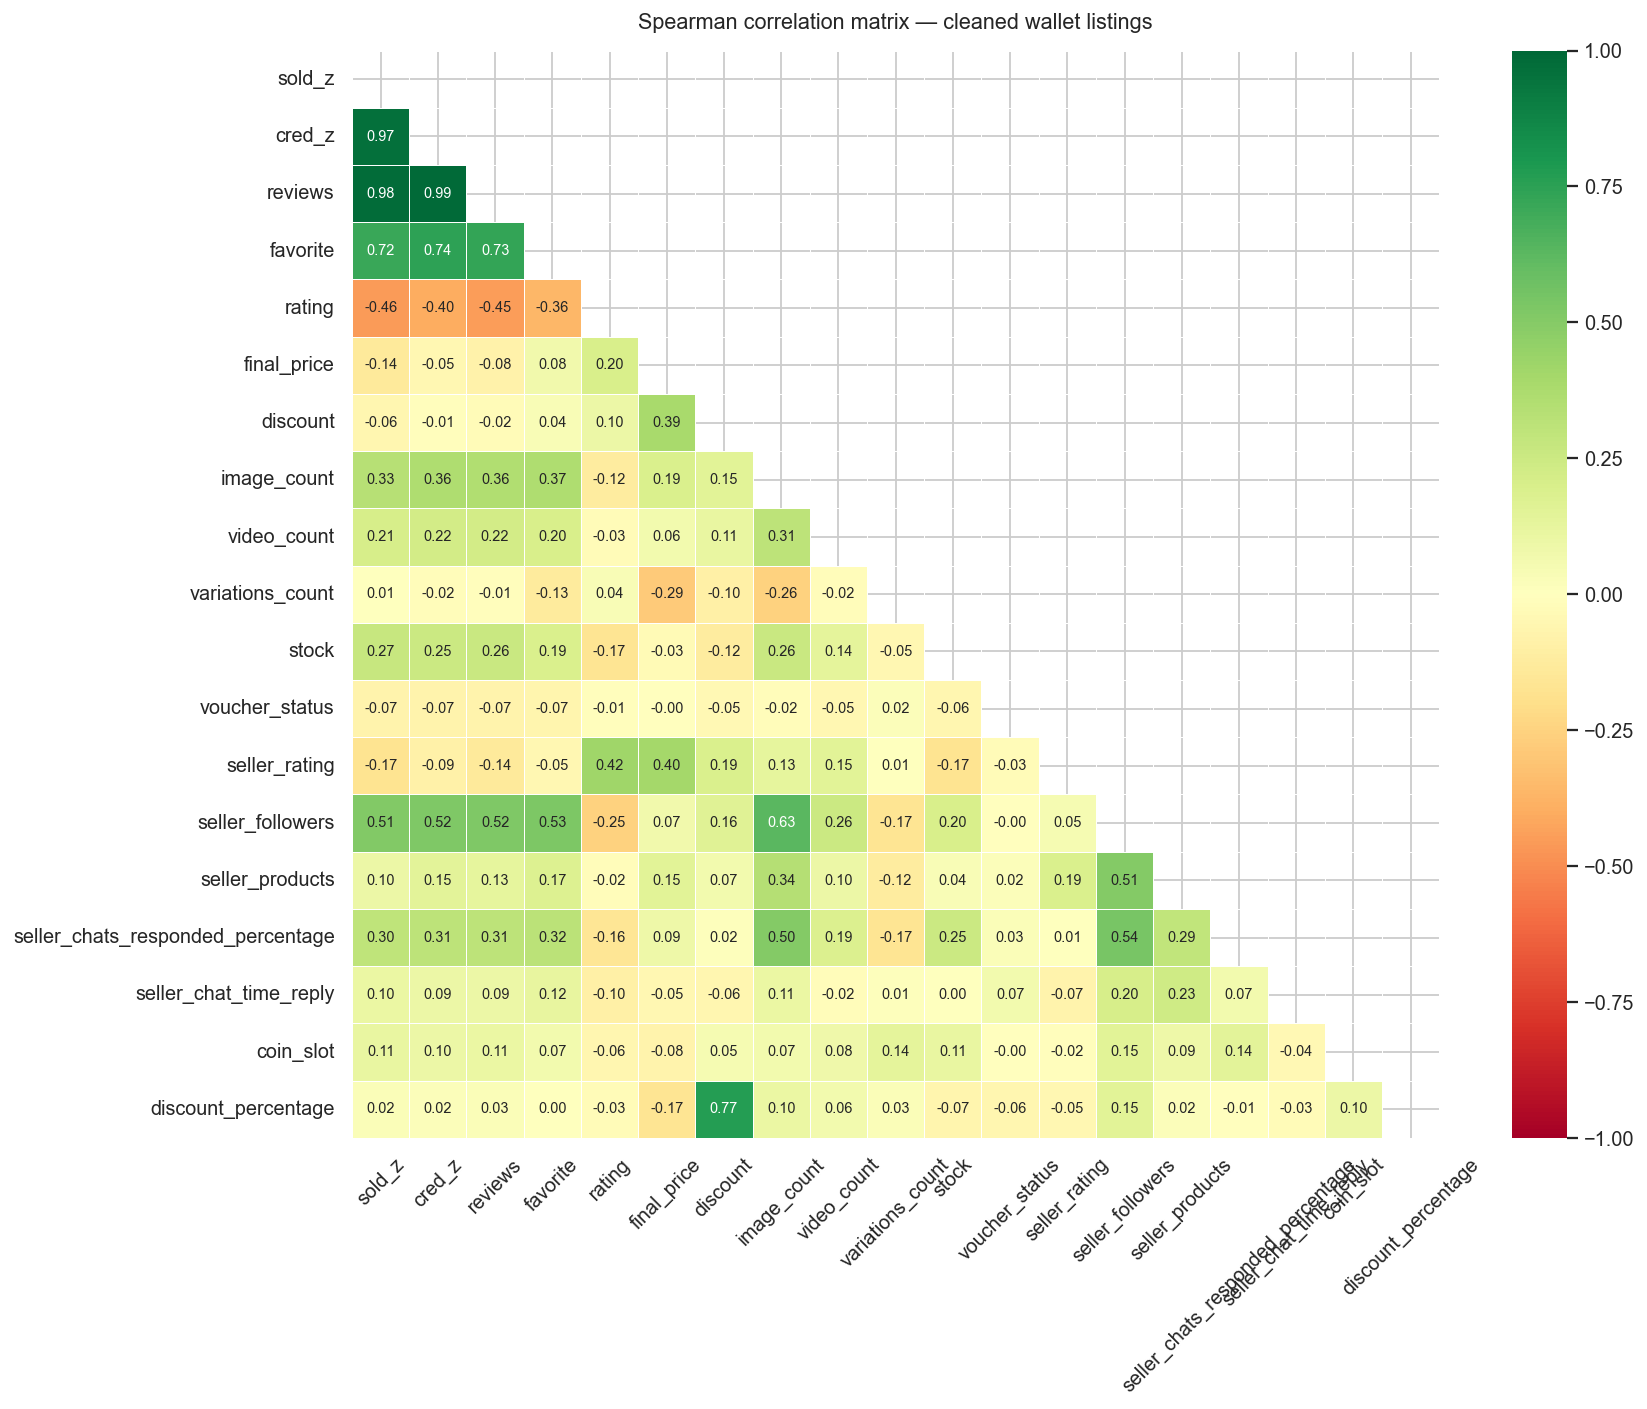


── Spearman ρ vs sold_z (ranked) ──
  reviews                                  +0.978  ███████████████████
  cred_z                                   +0.966  ███████████████████
  favorite                                 +0.717  ██████████████
  seller_followers                         +0.511  ██████████
  image_count                              +0.334  ██████
  seller_chats_responded_percentage        +0.303  ██████
  stock                                    +0.273  █████
  video_count                              +0.206  ████
  coin_slot                                +0.113  ██
  seller_chat_time_reply                   +0.103  ██
  seller_products                          +0.100  █
  discount_percentage                      +0.024  
  variations_count                         +0.006  
  discount                                 -0.057  █
  voucher_status                           -0.071  █
  final_price                              -0.140  ██
  seller_rating                        

In [53]:
# ── Master heatmap — which features correlate with GMV? ──────────
corr_cols = [
    'sold_z', 'cred_z', 'reviews', 'favorite', 'rating',
    'final_price', 'discount', 'image_count', 'video_count',
    'variations_count', 'stock', 'voucher_status',
    'seller_rating', 'seller_followers', 'seller_products',
    'seller_chats_responded_percentage', 'seller_chat_time_reply', 
    'coin_slot', 'discount_percentage',
]

spearman_mx = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(spearman_mx, dtype=bool))
sns.heatmap(
    spearman_mx, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white', square=True, ax=ax
)
ax.set_title('Spearman correlation matrix — cleaned wallet listings', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

sold_corr = spearman_mx['sold_z'].drop('sold_z').sort_values(ascending=False)
print("\n── Spearman ρ vs sold_z (ranked) ──")
for feat, val in sold_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")

rating_cred_corr = spearman_mx['cred_z'].drop('cred_z').sort_values(ascending=False)
print("\n── Spearman ρ vs raticred_zng_credibility (ranked) ──")
for feat, val in rating_cred_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")

### Pearson

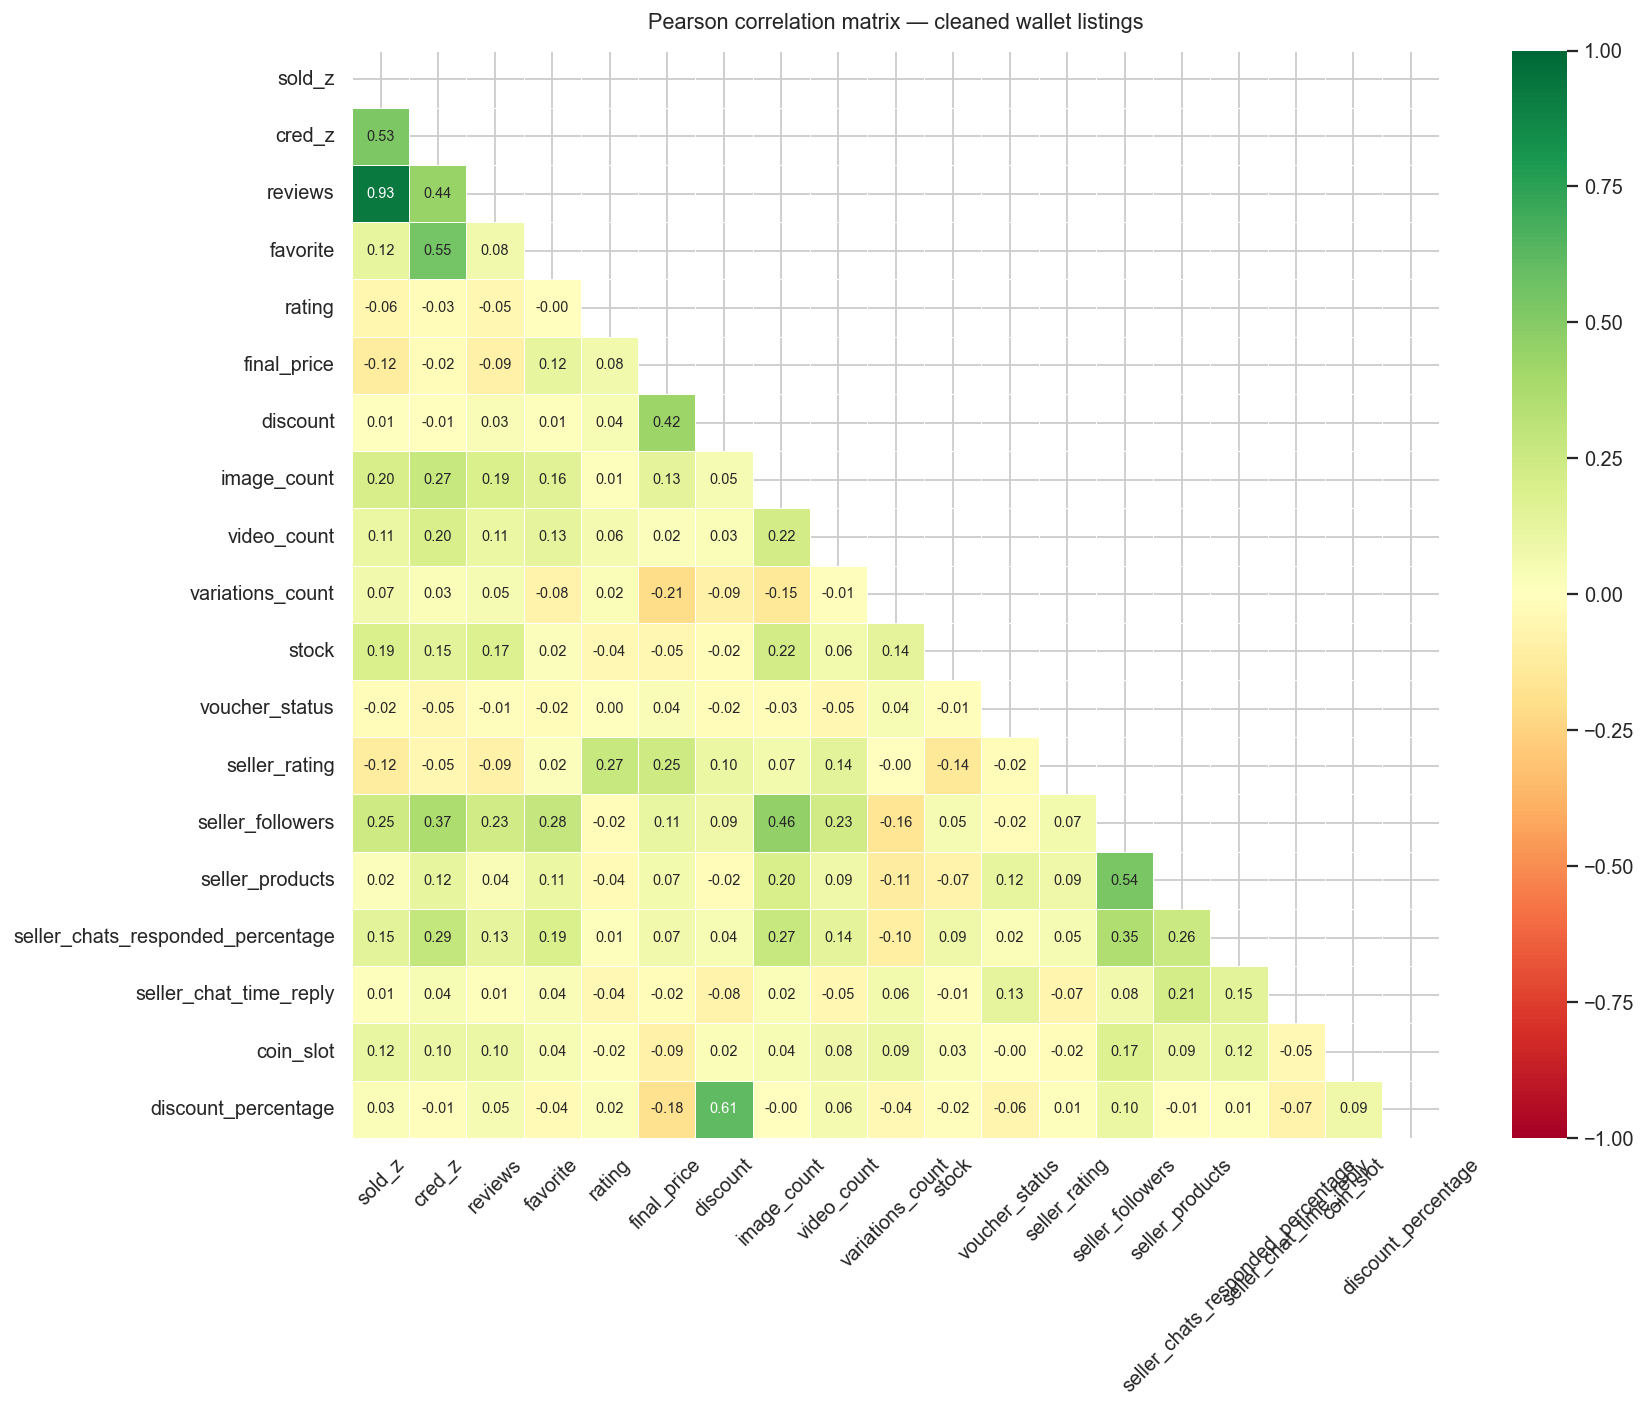


── Pearson r vs sold_z (ranked) ──
  reviews                                  +0.928  ██████████████████
  cred_z                                   +0.530  ██████████
  seller_followers                         +0.248  ████
  image_count                              +0.205  ████
  stock                                    +0.194  ███
  seller_chats_responded_percentage        +0.145  ██
  favorite                                 +0.121  ██
  coin_slot                                +0.116  ██
  video_count                              +0.109  ██
  variations_count                         +0.074  █
  discount_percentage                      +0.027  
  seller_products                          +0.016  
  seller_chat_time_reply                   +0.009  
  discount                                 +0.005  
  voucher_status                           -0.017  
  rating                                   -0.060  █
  final_price                              -0.119  ██
  seller_rating              

In [54]:
# ── Master heatmap — which features correlate with GMV? ──────────
corr_cols = [
    'sold_z', 'cred_z', 'reviews', 'favorite', 'rating',
    'final_price', 'discount', 'image_count', 'video_count',
    'variations_count', 'stock', 'voucher_status',
    'seller_rating', 'seller_followers', 'seller_products',
    'seller_chats_responded_percentage', 'seller_chat_time_reply', 
    'coin_slot', 'discount_percentage',
]

pearson_mx = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(pearson_mx, dtype=bool))
sns.heatmap(
    pearson_mx, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white', square=True, ax=ax
)
ax.set_title('Pearson correlation matrix — cleaned wallet listings', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

sold_corr = pearson_mx['sold_z'].drop('sold_z').sort_values(ascending=False)
print("\n── Pearson r vs sold_z (ranked) ──")
for feat, val in sold_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")

rating_cred_corr = pearson_mx['cred_z'].drop('cred_z').sort_values(ascending=False)
print("\n── Pearson r vs cred_z (ranked) ──")
for feat, val in rating_cred_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")